<a href="https://colab.research.google.com/github/amenidhawadi/deep-learning/blob/main/final_notebook_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from imblearn.over_sampling import SMOTE
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import warnings
warnings.filterwarnings('ignore')

In [3]:
tf.random.set_seed(42)
np.random.seed(42)

In [5]:
df = pd.read_csv('/content/sample_data/heart (1).csv')
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (918, 12)


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [6]:
print(df.isnull().sum())

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64


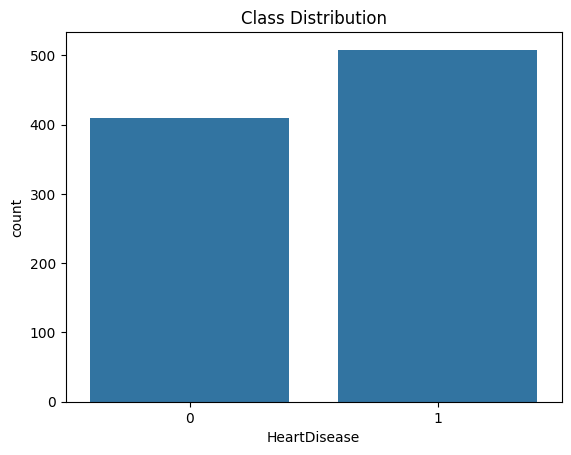

In [7]:
sns.countplot(x='HeartDisease', data=df)
plt.title('Class Distribution')
plt.show()

In [8]:
df['RestingBP'] = df['RestingBP'].replace(0, df['RestingBP'].median())
df['Cholesterol'] = df['Cholesterol'].replace(0, df['Cholesterol'].median())


In [9]:
cat_cols = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le


In [10]:
X = df.drop('HeartDisease', axis=1)
y = df['HeartDisease']

In [11]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

In [12]:
num_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_val[num_cols] = scaler.transform(X_val[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [13]:
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

In [14]:
print(f"Original training size: {X_train.shape} -> Resampled: {X_train_resampled.shape}")

Original training size: (550, 11) -> Resampled: (608, 11)


In [15]:
def create_mlp(input_dim, dropout_rate=0.3, lr=1e-3):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(dropout_rate),
        layers.Dense(64, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(dropout_rate),
        layers.Dense(32, activation='relu'),
        layers.Dropout(dropout_rate),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=lr),
                  loss='binary_crossentropy',
                  metrics=['accuracy', keras.metrics.AUC(name='auc')])
    return model

In [16]:
def create_cnn(input_dim, dropout_rate=0.3, lr=1e-3):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Reshape((input_dim, 1)),
        layers.Conv1D(64, kernel_size=3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling1D(pool_size=2),
        layers.Conv1D(128, kernel_size=3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.GlobalAveragePooling1D(),
        layers.Dropout(dropout_rate),
        layers.Dense(64, activation='relu'),
        layers.Dropout(dropout_rate),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=lr),
                  loss='binary_crossentropy',
                  metrics=['accuracy', keras.metrics.AUC(name='auc')])
    return model

In [17]:

def create_lstm(input_dim, dropout_rate=0.3, lr=1e-3):
    model = keras.Sequential([
        layers.Input(shape=(input_dim, 1)),
        layers.LSTM(64, return_sequences=True, dropout=dropout_rate),
        layers.LSTM(32, dropout=dropout_rate),
        layers.Dense(32, activation='relu'),
        layers.Dropout(dropout_rate),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=lr),
                  loss='binary_crossentropy',
                  metrics=['accuracy', keras.metrics.AUC(name='auc')])
    return model

In [18]:
def create_transformer(input_dim, d_model=64, num_heads=4, ff_dim=128, dropout_rate=0.1, lr=1e-3):
    inputs = layers.Input(shape=(input_dim,))
    x = layers.Dense(d_model)(inputs)
    pos_encoding = layers.Embedding(input_dim, d_model)
    positions = tf.range(start=0, limit=input_dim, delta=1)
    x = x + pos_encoding(positions)
    attn_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model//num_heads)(x, x)
    x = layers.Add()([x, attn_output])
    x = layers.LayerNormalization()(x)
    ffn = keras.Sequential([
        layers.Dense(ff_dim, activation='relu'),
        layers.Dense(d_model)
    ])
    ffn_out = ffn(x)
    x = layers.Add()([x, ffn_out])
    x = layers.LayerNormalization()(x)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)
    model = Model(inputs, outputs)
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=lr),
                  loss='binary_crossentropy',
                  metrics=['accuracy', keras.metrics.AUC(name='auc')])
    return model

In [20]:
print("X_train_resampled shape:", X_train_resampled.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)

X_train_resampled shape: (608, 11)
X_val shape: (184, 11)
X_test shape: (184, 11)
